# Logistic regression

Run in order: **Data → Model → Training → Evaluation → Visualization**.

## 1. Data

Generate 50 binary labels using

$$
p_i^*=\operatorname{sigmoid}(2x_i+1),
\qquad y_i\sim\operatorname{Bernoulli}(p_i^*).
$$

The random seed makes the data reproducible.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# 1. Generate toy dataset
# ============================================================
torch.manual_seed(0)

N = 50
x = torch.linspace(-3, 3, N).reshape(-1, 1)

true_w = torch.tensor([[2.0]])
true_b = torch.tensor([[1.0]])

true_prob = torch.sigmoid(x @ true_w + true_b)
y = torch.bernoulli(true_prob)

### View the dataset

Each dot represents an input–label pair $(x_i,y_i)$.

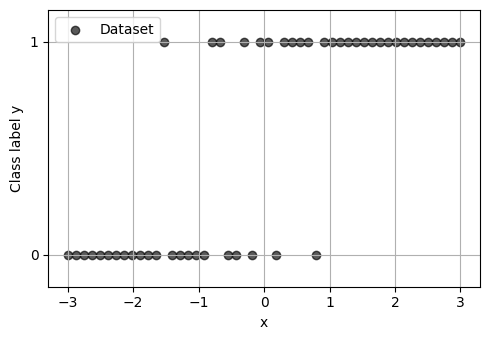

In [2]:
# ============================================================
# Plot dataset only
# ============================================================
plt.figure(figsize=(5, 3.5))
plt.scatter(x.numpy(), y.numpy(), color="black", alpha=0.65, label="Dataset")
plt.xlabel("x")
plt.ylabel("Class label y")
plt.yticks([0, 1])
plt.ylim(-0.15, 1.15)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Model

Predict the probability of class 1:

$$
p_i=\operatorname{sigmoid}(wx_i+b),
\qquad \operatorname{sigmoid}(z)=\frac{1}{1+e^{-z}}.
$$

Minimize binary cross-entropy with a weight penalty:

$$
\mathcal L(w,b)
=-\frac{1}{N}\sum_{i=1}^{N}[y_i\log p_i+(1-y_i)\log(1-p_i)]
+\frac{\lambda}{2}w^2.
$$

The bias is not penalized. `BCEWithLogitsLoss` takes raw scores $wx_i+b$, without applying sigmoid first.

In [4]:
lam = 1e-3
bce_loss = nn.BCEWithLogitsLoss()


def compute_loss(w, b):
    logits = x @ w + b
    data_loss = bce_loss(logits, y)
    reg_loss = 0.5 * lam * torch.sum(w ** 2)
    return data_loss + reg_loss


w = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, 1, requires_grad=True)

## 3. Training

Update the parameters using gradient descent:

$$
\theta\leftarrow\theta-\eta\nabla\mathcal L(\theta).
$$

`backward()` computes gradients; `zero_()` clears them after each update. Set `print_every = 1` to print every loss.

In [5]:
lr = 0.1
num_steps = 500
save_steps = [0, 1, 5, 20, 100, 499]
print_every = 50  # Set to 1 to print every step.

loss_history = []
snapshots = {}

for k in range(num_steps):
    # Compute loss before the update.
    loss = compute_loss(w, b)
    loss_history.append(loss.item())

    if k in save_steps:
        snapshots[k] = (w.detach().clone(), b.detach().clone())

    if k % print_every == 0 or k == num_steps - 1:
        print(f"Step {k:3d}: loss = {loss.item():.6f}")

    # Backpropagation
    loss.backward()

    # Gradient descent update
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Reset gradients.
    w.grad.zero_()
    b.grad.zero_()

w_gd = w.detach().clone()
b_gd = b.detach().clone()

print("\nTrue generating parameters")
print(f"w = {true_w.item():.4f}, b = {true_b.item():.4f}")
print("\nGradient descent solution")
print(f"w = {w_gd.item():.4f}, b = {b_gd.item():.4f}")

Step   0: loss = 2.047940
Step  50: loss = 0.336117
Step 100: loss = 0.301278
Step 150: loss = 0.292596
Step 200: loss = 0.289312
Step 250: loss = 0.287859
Step 300: loss = 0.287163
Step 350: loss = 0.286813
Step 400: loss = 0.286631
Step 450: loss = 0.286536
Step 499: loss = 0.286485

True generating parameters
w = 2.0000, b = 1.0000

Gradient descent solution
w = 1.7964, b = 0.6435


## 4. Evaluation

Predict class 1 when the fitted probability is at least 0.5. Report the final loss and **training accuracy**; these do not measure generalization.

In [6]:
with torch.no_grad():
    final_loss = compute_loss(w_gd, b_gd).item()
    train_prob = torch.sigmoid(x @ w_gd + b_gd)
    train_pred = (train_prob >= 0.5).float()
    train_accuracy = (train_pred == y).float().mean().item()

print(f"Loss after {num_steps} updates: {final_loss:.6f}")
print(f"Training accuracy: {100 * train_accuracy:.1f}%")

Loss after 500 updates: 0.286484
Training accuracy: 88.0%


## 5. Visualization

Blue curves show selected gradient-descent fits; red shows the true probability. The right panel shows losses before the corresponding updates.

**Question:** How does the probability curve change as the loss decreases?

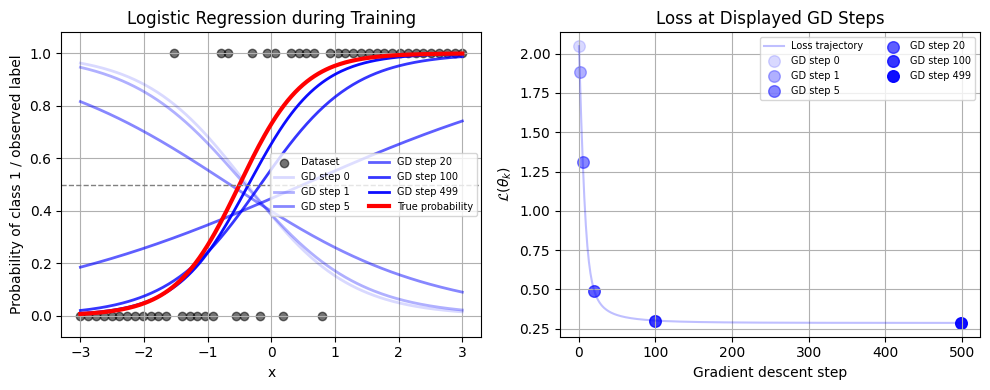

In [7]:
x_plot = torch.linspace(-3, 3, 200).reshape(-1, 1)
p_true_plot = torch.sigmoid(x_plot @ true_w + true_b)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
alphas = torch.linspace(0.15, 0.95, len(snapshots))

# Left: fitted probability curves at selected GD steps.
ax = axes[0]
ax.scatter(x.numpy(), y.numpy(), color="black", alpha=0.55, label="Dataset")

for alpha, (k, (wk, bk)) in zip(alphas, snapshots.items()):
    p_gd_step = torch.sigmoid(x_plot @ wk + bk)
    ax.plot(x_plot.numpy(), p_gd_step.numpy(), color="blue",
            alpha=float(alpha), linewidth=2, label=f"GD step {k}")

ax.plot(x_plot.numpy(), p_true_plot.numpy(), color="red",
        linewidth=3, label="True probability")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Logistic Regression during Training")
ax.set_xlabel("x")
ax.set_ylabel("Probability of class 1 / observed label")
ax.set_ylim(-0.08, 1.08)
ax.grid(True)
ax.legend(fontsize=7, ncol=2)

# Right: losses at the same saved steps.
ax = axes[1]
ax.plot(range(num_steps), loss_history, color="blue",
        alpha=0.25, linewidth=1.5, label="Loss trajectory")
for alpha, k in zip(alphas, snapshots):
    ax.scatter(k, loss_history[k], color="blue", alpha=float(alpha),
               s=70, label=f"GD step {k}")

ax.set_title("Loss at Displayed GD Steps")
ax.set_xlabel("Gradient descent step")
ax.set_ylabel(r"$\mathcal{L}(\theta_k)$")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)

# ============================================================
# 5. Save and show
# ============================================================
plt.tight_layout()
fig.savefig("logistic_gd_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()